# 4. Inference - ResNet18 Terbaru

Notebook ini hanya untuk inference ResNet18 terbaru.
Hasil menampilkan gambar, label (jernih/keruh), dan confidence score.

## Cara Penggunaan:
1. Letakkan foto di folder `F:\\TA1\\test_images\\`
2. Jalankan cell single image atau batch prediction
3. Lihat hasil prediksi dan confidence

In [ ]:
# ============================================================================
# 4_Inference.ipynb - Inference ResNet18 Terbaru
# ============================================================================
# Purpose: Prediksi turbidity pada foto baru dengan ResNet18
#   - Single image prediction: tampilkan gambar + label + confidence
#   - Batch prediction: ringkasan hasil + export CSV
# ============================================================================

import torch
import torch.nn as nn
from torchvision import models, transforms
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Class names
class_names = ['Jernih (Clear)', 'Keruh (Turbid)']

🖥️ Device: cuda


In [ ]:
# ============================================================================
# 📁 FOLDER SETUP
# ============================================================================
test_images_dir = Path('F:\\TA1\\test_images')
test_images_dir.mkdir(exist_ok=True)

print(f"Test images folder: {test_images_dir}")
print(f"Current images: {list(test_images_dir.glob('*.*'))}")

# ============================================================================
# 🤖 LOAD RESNET18 TERBARU
# ============================================================================
print("\n" + "=" * 70)
print("Loading ResNet18 (latest)...")
print("=" * 70)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
 )

candidate_paths = [
    Path('resnet18_final_best_practice.pth'),
    Path('resnet18_best.pth'),
    Path('resnet18_final.pth'),
    Path('checkpoints') / 'resnet18_final_best_practice.pth',
    Path('checkpoints') / 'resnet18_best.pth',
    Path('checkpoints') / 'resnet18_final.pth',
]

model_path = next((p for p in candidate_paths if p.exists()), None)
if model_path is None:
    raise FileNotFoundError(
        "Model file not found. Expected one of: "
        "resnet18_final_best_practice.pth / resnet18_best.pth / resnet18_final.pth"
    )

checkpoint = torch.load(str(model_path), map_location=device)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model = model.to(device).eval()

print(f"Model loaded: {model_path}")
print(f"Device: {device}")

✅ Test images folder: F:\TA1\test_images
📝 Letakkan foto Anda di folder ini!
📌 Format: JPG, PNG
📌 Current images: [WindowsPath('F:/TA1/test_images/1.jpeg'), WindowsPath('F:/TA1/test_images/2.jpeg'), WindowsPath('F:/TA1/test_images/3.avif'), WindowsPath('F:/TA1/test_images/4.jpeg'), WindowsPath('F:/TA1/test_images/5.jpg'), WindowsPath('F:/TA1/test_images/6.jpeg'), WindowsPath('F:/TA1/test_images/7.jpg')]

Loading XceptionNet...


f:\TA1\venv_fresh\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


✅ XceptionNet loaded: F:\TA1\xceptionnet_final.pth

Loading ResNet18...
✅ ResNet18 loaded: F:\TA1\resnet18_final.pth

✅ KEDUA MODEL SIAP!


In [ ]:
# ============================================================================
# 🔧 PREPROCESSING & PREDICTION FUNCTIONS
# ============================================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def preprocess_image(image_path):
    """Load dan preprocess single image untuk ResNet18."""
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    return image_tensor, image

def predict_image(image_path):
    """Predict single image dan return label + confidence."""
    image_tensor, original_image = preprocess_image(image_path)
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.nn.functional.softmax(logits, dim=1)
        pred_idx = int(torch.argmax(probs, dim=1).item())
        confidence = float(probs[0, pred_idx].item())
    return pred_idx, class_names[pred_idx], confidence, probs[0].cpu().numpy(), original_image

print("Preprocessing dan prediction siap")

✅ Fungsi preprocessing dan prediction siap!


⚠️  File tidak ditemukan. Menggunakan: 1.jpeg
📷 FOTO: 1.jpeg

🌊 XCEPTIONNET:
   Prediksi   : Keruh (Turbid)
   Confidence : 72.68%
   Probabilities: Jernih=0.2732, Keruh=0.7268

🎯 RESNET18:
   Prediksi   : Jernih (Clear)
   Confidence : 96.22%
   Probabilities: Jernih=0.9622, Keruh=0.0378

⚠️  KEDUA MODEL BERBEDA (DISAGREE)


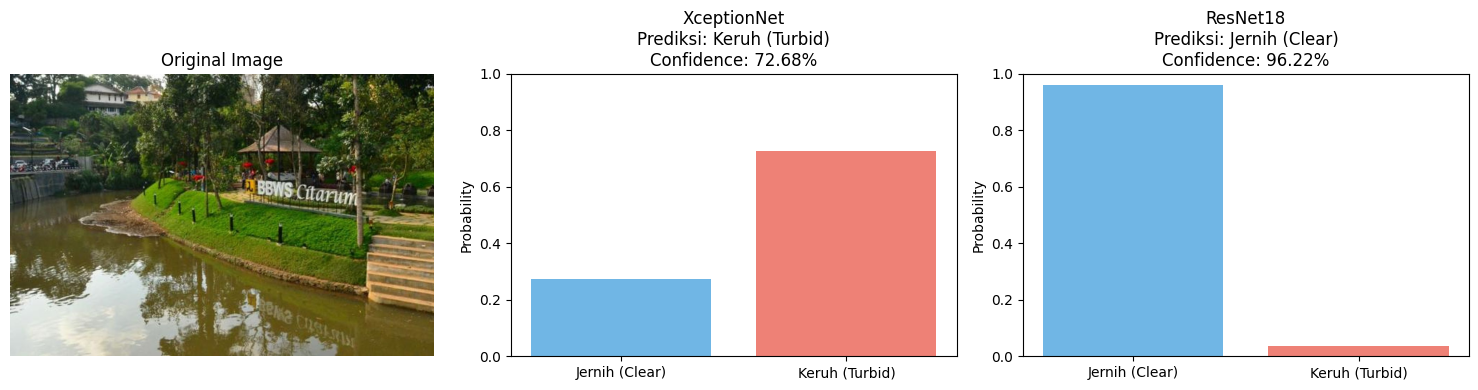

✅ Visualisasi disimpan: single_prediction_comparison.png


In [ ]:
# ============================================================================
# 📷 SINGLE IMAGE PREDICTION
# ============================================================================

test_image_path = test_images_dir / 'clear_water.jpg'  # Ubah sesuai foto Anda

if not test_image_path.exists():
    available_images = list(test_images_dir.glob('*.*'))
    if available_images:
        test_image_path = available_images[0]
        print(f"File default tidak ditemukan, menggunakan: {test_image_path.name}")
    else:
        test_image_path = None
        print("Tidak ada foto di folder test_images/")

if test_image_path is not None:
    pred_idx, pred_label, confidence, probs, original_image = predict_image(test_image_path)

    print("=" * 80)
    print(f"Foto: {Path(test_image_path).name}")
    print(f"Prediksi: {pred_label}")
    print(f"Confidence: {confidence:.2%}")
    print(f"Probabilities: Jernih={probs[0]:.4f}, Keruh={probs[1]:.4f}")
    print("=" * 80)

    # Visualisasi
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.imshow(original_image)
    ax.set_title(f"Prediksi: {pred_label}\nConfidence: {confidence:.2%}", fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================================
# 📁 BATCH PREDICTION (SEMUA FOTO DI FOLDER)
# ============================================================================

image_extensions = ('*.jpg', '*.jpeg', '*.png', '*.avif', '*.webp', '*.bmp',
                    '*.JPG', '*.JPEG', '*.PNG', '*.AVIF', '*.WEBP', '*.BMP')

image_files = []
for ext in image_extensions:
    image_files.extend(test_images_dir.glob(ext))
image_files = sorted(list(set(image_files)))

if not image_files:
    print("Tidak ada foto di folder test_images/")
else:
    results = []
    print(f"Memproses {len(image_files)} foto...")

    for idx, image_path in enumerate(image_files, 1):
        pred_idx, pred_label, confidence, probs, _ = predict_image(image_path)
        results.append({
            'Filename': image_path.name,
            'Prediction': pred_label,
            'Confidence': f"{confidence:.4f}",
            'Prob_Jernih': f"{probs[0]:.4f}",
            'Prob_Keruh': f"{probs[1]:.4f}"
        })
        print(f"{idx}. {image_path.name} -> {pred_label} ({confidence:.2%})")

    results_df = pd.DataFrame(results)
    print("\nRESULTS SUMMARY:")
    print(results_df.to_string(index=False))

    # Save CSV
    logs_dir = Path('logs')
    logs_dir.mkdir(exist_ok=True)
    output_csv = logs_dir / 'inference_results_resnet18.csv'
    results_df.to_csv(output_csv, index=False)
    print(f"\nHasil disimpan: {output_csv}")

    # Visualisasi sample (maksimal 6 gambar)
    sample_files = image_files[:min(6, len(image_files))]
    if sample_files:
        fig, axes = plt.subplots(2, 3, figsize=(12, 8))
        axes = axes.flatten()
        for ax, img_path in zip(axes, sample_files):
            pred_idx, pred_label, confidence, _, original_image = predict_image(img_path)
            ax.imshow(original_image)
            ax.set_title(f"{img_path.name}\n{pred_label}\n{confidence:.2%}", fontsize=9)
            ax.axis('off')
        for ax in axes[len(sample_files):]:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

🔄 Memproses 7 foto...

1. 1.jpeg
   XceptionNet: Keruh (Turbid) (72.68%)
   ResNet18   : Jernih (Clear) (96.22%)
   Match      : ⚠️ NO

2. 2.jpeg
   XceptionNet: Jernih (Clear) (100.00%)
   ResNet18   : Jernih (Clear) (100.00%)
   Match      : ✅ YES

3. 3.avif
   XceptionNet: Jernih (Clear) (100.00%)
   ResNet18   : Jernih (Clear) (98.86%)
   Match      : ✅ YES

4. 4.jpeg
   XceptionNet: Jernih (Clear) (99.98%)
   ResNet18   : Jernih (Clear) (99.96%)
   Match      : ✅ YES

5. 5.jpg
   XceptionNet: Jernih (Clear) (100.00%)
   ResNet18   : Jernih (Clear) (100.00%)
   Match      : ✅ YES

6. 6.jpeg
   XceptionNet: Jernih (Clear) (92.16%)
   ResNet18   : Jernih (Clear) (73.36%)
   Match      : ✅ YES

7. 7.jpg
   XceptionNet: Keruh (Turbid) (100.00%)
   ResNet18   : Keruh (Turbid) (100.00%)
   Match      : ✅ YES

📊 RESULTS SUMMARY
Filename XceptionNet_Pred  XceptionNet_Conf  ResNet18_Pred  ResNet18_Conf Agree
  1.jpeg   Keruh (Turbid)          0.726768 Jernih (Clear)       0.962154 ⚠️ NO
  2